In [1]:

import os
import ast
import pickle
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap

from sequence_encoder import run_encoder

warnings.filterwarnings("ignore")


/Users/saanvibhu/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11
plt.rcParams["figure.dpi"] = 120


In [3]:

DATA_DIR = "data"
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")

TRAIN_CSV = os.path.join(PROCESSED_DIR, "train_dataset.csv")
VAL_CSV   = os.path.join(PROCESSED_DIR, "val_dataset.csv")
TEST_CSV  = os.path.join(PROCESSED_DIR, "test_dataset.csv")

TRAIN_EMB = os.path.join(PROCESSED_DIR, "train_embeddings.pkl")
VAL_EMB   = os.path.join(PROCESSED_DIR, "val_embeddings.pkl")
TEST_EMB  = os.path.join(PROCESSED_DIR, "test_embeddings.pkl")

FIG_DIR = os.path.join(PROCESSED_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

for path in [TRAIN_CSV, VAL_CSV, TEST_CSV]:
    print(path, "->", os.path.exists(path))


data/processed/train_dataset.csv -> True
data/processed/val_dataset.csv -> True
data/processed/test_dataset.csv -> True


load splits

In [4]:

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)


Train shape: (159, 7)
Val shape: (20, 7)
Test shape: (20, 7)


In [5]:

print("Train columns:")
print(train_df.columns.tolist())


Train columns:
['uniprot_id', 'sequence', 'raw_text', 'go_terms', 'clean_text', 'cluster_id', 'split']


In [6]:

train_df.head()


,uniprot_id,sequence,raw_text,go_terms,clean_text,cluster_id,split
0,A0A0C5B5G6,MRWQEMGYIFYPRKLR,Regulates insulin sensitivity and metabolic ho...,"['GO:0005615', 'GO:0005739', 'GO:0005634', 'GO...",Regulates insulin sensitivity and metabolic ho...,6,train
1,A0JNW5,MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...,Tube-forming lipid transport protein which med...,"['GO:0005829', 'GO:0005769', 'GO:0062069', 'GO...",Tube-forming lipid transport protein which med...,7,train
2,A0JP26,MVAEVCSMPAASAVKKPFDLRSKMGKWCHHRFPCCRGSGKSNMGTS...,NaN,[],"Binding to cells via a high affinity receptor,...",64,train
3,A0PK11,MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...,Plays a key role to hearing function. Required...,"['GO:0032421', 'GO:0060171', 'GO:0060088', 'GO...",Plays a key role to hearing function. Required...,155,train
4,A1A4S6,MGLQPLEFSDCYLDSPWFRERIRAHEAELERTNKFIKELIKDGKNL...,GTPase-activating protein that catalyzes the c...,"['GO:0005829', 'GO:0010008', 'GO:0048471', 'GO...",GTPase-activating protein that catalyzes the c...,37,train


In [7]:

required_cols = ["uniprot_id", "sequence"]

for col in required_cols:
    assert col in train_df.columns, f"Missing required column in train split: {col}"
    assert col in val_df.columns, f"Missing required column in val split: {col}"
    assert col in test_df.columns, f"Missing required column in test split: {col}"

print("all columns required found.")


all columns required found.


In [8]:

for df in [train_df, val_df, test_df]:
    df["sequence"] = df["sequence"].astype(str)
    df["seq_len"] = df["sequence"].apply(len)

summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "count": [len(train_df), len(val_df), len(test_df)],
    "mean_seq_len": [train_df["seq_len"].mean(), val_df["seq_len"].mean(), test_df["seq_len"].mean()],
    "median_seq_len": [train_df["seq_len"].median(), val_df["seq_len"].median(), test_df["seq_len"].median()],
    "min_seq_len": [train_df["seq_len"].min(), val_df["seq_len"].min(), test_df["seq_len"].min()],
    "max_seq_len": [train_df["seq_len"].max(), val_df["seq_len"].max(), test_df["seq_len"].max()]
})

summary


,split,count,mean_seq_len,median_seq_len,min_seq_len,max_seq_len
0,train,159,533.735849,435.0,16,2555
1,val,20,525.350000,468.0,76,1044
2,test,20,617.750000,428.0,113,2624


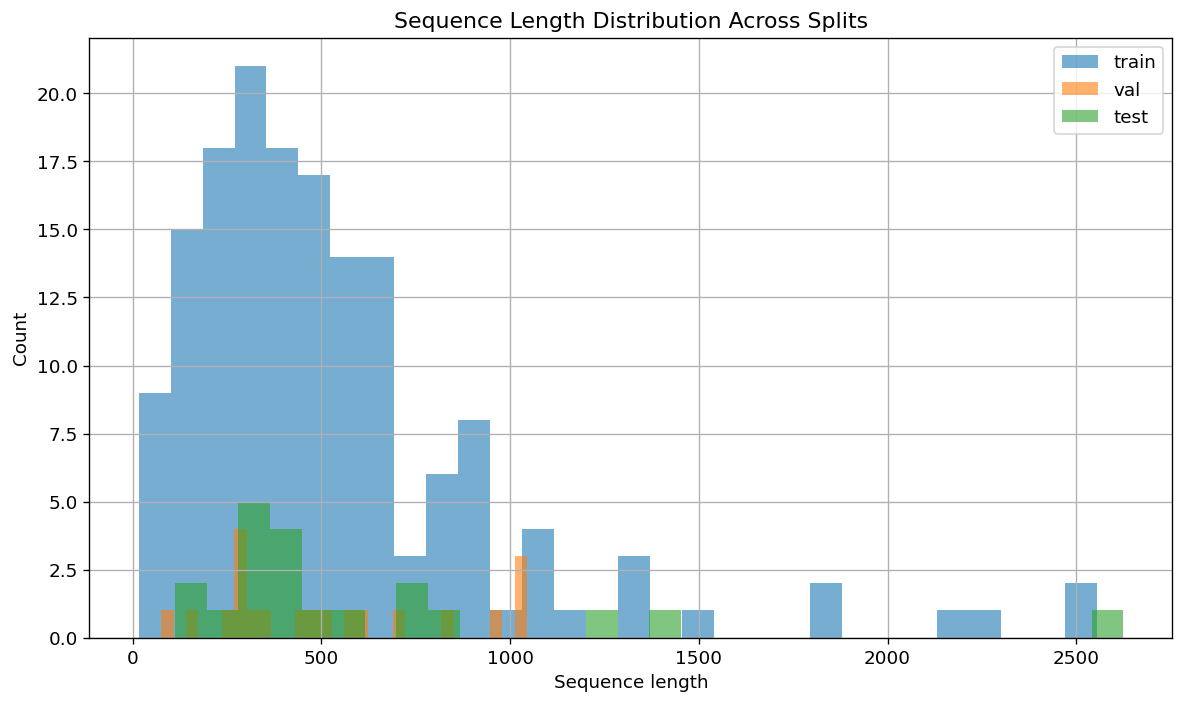

In [9]:

plt.figure(figsize=(10, 6))
plt.hist(train_df["seq_len"], bins=30, alpha=0.6, label="train")
plt.hist(val_df["seq_len"], bins=30, alpha=0.6, label="val")
plt.hist(test_df["seq_len"], bins=30, alpha=0.6, label="test")
plt.xlabel("Sequence length")
plt.ylabel("Count")
plt.title("Sequence Length Distribution Across Splits")
plt.legend()
plt.tight_layout()
plt.show()


In [10]:

def try_parse_go_terms(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if not x:
            return []
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return parsed
        except:
            pass
        if ";" in x:
            return [item.strip() for item in x.split(";") if item.strip()]
        if "," in x:
            return [item.strip() for item in x.split(",") if item.strip()]
        return [x]
    return []

for df in [train_df, val_df, test_df]:
    if "go_terms" in df.columns:
        df["go_terms_list"] = df["go_terms"].apply(try_parse_go_terms)

print("GO term parsing complete if go_terms column exists.")


GO term parsing complete if go_terms column exists.


In [11]:

RUN_EMBEDDING_STEP = True
BATCH_SIZE = 4
MODEL_SIZE = "small"


In [12]:

if RUN_EMBEDDING_STEP:
    if not os.path.exists(TRAIN_EMB):
        run_encoder(TRAIN_CSV, TRAIN_EMB, batch_size=BATCH_SIZE, model_size=MODEL_SIZE)
    else:
        print("Train embeddings already exist.")

    if not os.path.exists(VAL_EMB):
        run_encoder(VAL_CSV, VAL_EMB, batch_size=BATCH_SIZE, model_size=MODEL_SIZE)
    else:
        print("Val embeddings already exist.")

    if not os.path.exists(TEST_EMB):
        run_encoder(TEST_CSV, TEST_EMB, batch_size=BATCH_SIZE, model_size=MODEL_SIZE)
    else:
        print("Test embeddings already exist.")
else:
    print("Skipping embedding generation step.")


Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t30_150M_UR50D.pt" to /Users/saanvibhu/.cache/torch/hub/checkpoints/esm2_t30_150M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t30_150M_UR50D-contact-regression.pt" to /Users/saanvibhu/.cache/torch/hub/checkpoints/esm2_t30_150M_UR50D-contact-regression.pt
Processed 4/159 sequences
Processed 8/159 sequences
Processed 12/159 sequences
Processed 16/159 sequences
Processed 20/159 sequences
Processed 24/159 sequences
Processed 28/159 sequences
Processed 32/159 sequences
Processed 36/159 sequences
Processed 40/159 sequences
Processed 44/159 sequences
Processed 48/159 sequences
Processed 52/159 sequences
Processed 56/159 sequences
Processed 60/159 sequences
Processed 64/159 sequences
Processed 68/159 sequences
Processed 72/159 sequences
Processed 76/159 sequences
Processed 80/159 sequences
Processed 84/159 sequences
Processed 88/159 sequences
Processed 92/159 sequences
Processed 96/159 sequence

In [13]:

with open(TRAIN_EMB, "rb") as f:
    train_emb = pickle.load(f)

with open(VAL_EMB, "rb") as f:
    val_emb = pickle.load(f)

with open(TEST_EMB, "rb") as f:
    test_emb = pickle.load(f)

print("Train embeddings:", len(train_emb))
print("Val embeddings:", len(val_emb))
print("Test embeddings:", len(test_emb))


Train embeddings: 159
Val embeddings: 20
Test embeddings: 20


In [14]:

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

all_emb = {}
all_emb.update(train_emb)
all_emb.update(val_emb)
all_emb.update(test_emb)

X = []
meta_rows = []

for _, row in all_df.iterrows():
    pid = row["uniprot_id"]
    if pid in all_emb:
        X.append(all_emb[pid])
        meta_rows.append(row)

X = np.array(X)
meta_df = pd.DataFrame(meta_rows).reset_index(drop=True)

print("Embedding matrix shape:", X.shape)
print("Metadata shape:", meta_df.shape)


Embedding matrix shape: (199, 640)
Metadata shape: (199, 9)


In [15]:

meta_df.head()


,uniprot_id,sequence,raw_text,go_terms,clean_text,cluster_id,split,seq_len,go_terms_list
0,A0A0C5B5G6,MRWQEMGYIFYPRKLR,Regulates insulin sensitivity and metabolic ho...,"['GO:0005615', 'GO:0005739', 'GO:0005634', 'GO...",Regulates insulin sensitivity and metabolic ho...,6,train,16,"[GO:0005615, GO:0005739, GO:0005634, GO:000367..."
1,A0JNW5,MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...,Tube-forming lipid transport protein which med...,"['GO:0005829', 'GO:0005769', 'GO:0062069', 'GO...",Tube-forming lipid transport protein which med...,7,train,1464,"[GO:0005829, GO:0005769, GO:0062069, GO:012001..."
2,A0JP26,MVAEVCSMPAASAVKKPFDLRSKMGKWCHHRFPCCRGSGKSNMGTS...,NaN,[],"Binding to cells via a high affinity receptor,...",64,train,581,[]
3,A0PK11,MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...,Plays a key role to hearing function. Required...,"['GO:0032421', 'GO:0060171', 'GO:0060088', 'GO...",Plays a key role to hearing function. Required...,155,train,232,"[GO:0032421, GO:0060171, GO:0060088, GO:000760..."
4,A1A4S6,MGLQPLEFSDCYLDSPWFRERIRAHEAELERTNKFIKELIKDGKNL...,GTPase-activating protein that catalyzes the c...,"['GO:0005829', 'GO:0010008', 'GO:0048471', 'GO...",GTPase-activating protein that catalyzes the c...,37,train,786,"[GO:0005829, GO:0010008, GO:0048471, GO:000588..."


In [16]:

scale_features = True

if scale_features:
    X_input = StandardScaler().fit_transform(X)
else:
    X_input = X.copy()

print("UMAP input shape:", X_input.shape)


UMAP input shape: (199, 640)


In [17]:

UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_METRIC = "cosine"
UMAP_RANDOM_STATE = 42

reducer = umap.UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    random_state=UMAP_RANDOM_STATE
)

X_umap = reducer.fit_transform(X_input)

meta_df["umap_1"] = X_umap[:, 0]
meta_df["umap_2"] = X_umap[:, 1]

meta_df[["uniprot_id", "split", "umap_1", "umap_2"]].head()


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,uniprot_id,split,umap_1,umap_2
0,A0A0C5B5G6,train,-0.043391,9.012873
1,A0JNW5,train,-0.444973,8.652917
2,A0JP26,train,0.568430,8.732258
3,A0PK11,train,3.642735,7.635972
4,A1A4S6,train,1.711318,5.393338


Saved: data/processed/figures/umap_by_split.png


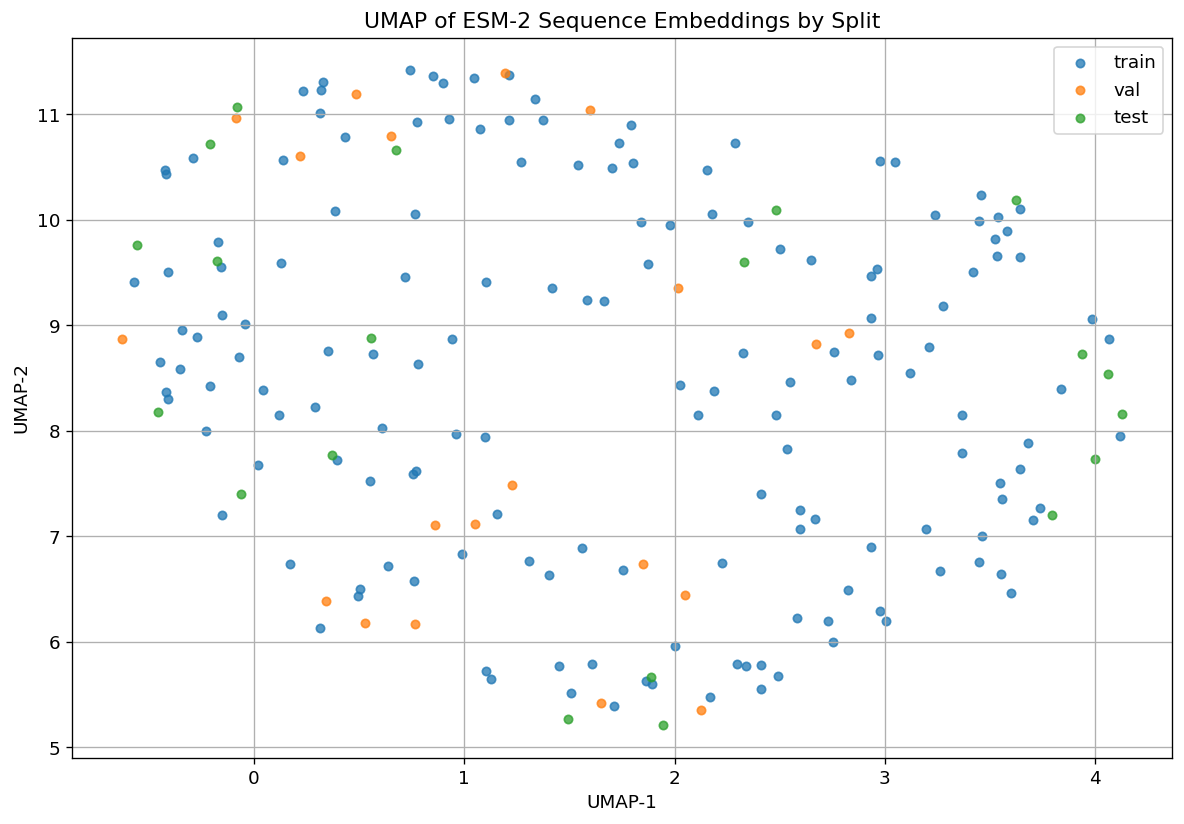

In [18]:

def save_current_figure(path):
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)

split_plot_path = os.path.join(FIG_DIR, "umap_by_split.png")

plt.figure(figsize=(10, 7))
for split in ["train", "val", "test"]:
    subset = meta_df[meta_df["split"] == split]
    plt.scatter(
        subset["umap_1"],
        subset["umap_2"],
        s=25,
        alpha=0.75,
        label=split
    )

plt.title("UMAP of ESM-2 Sequence Embeddings by Split")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.tight_layout()
save_current_figure(split_plot_path)
plt.show()


Saved: data/processed/figures/umap_by_sequence_length.png


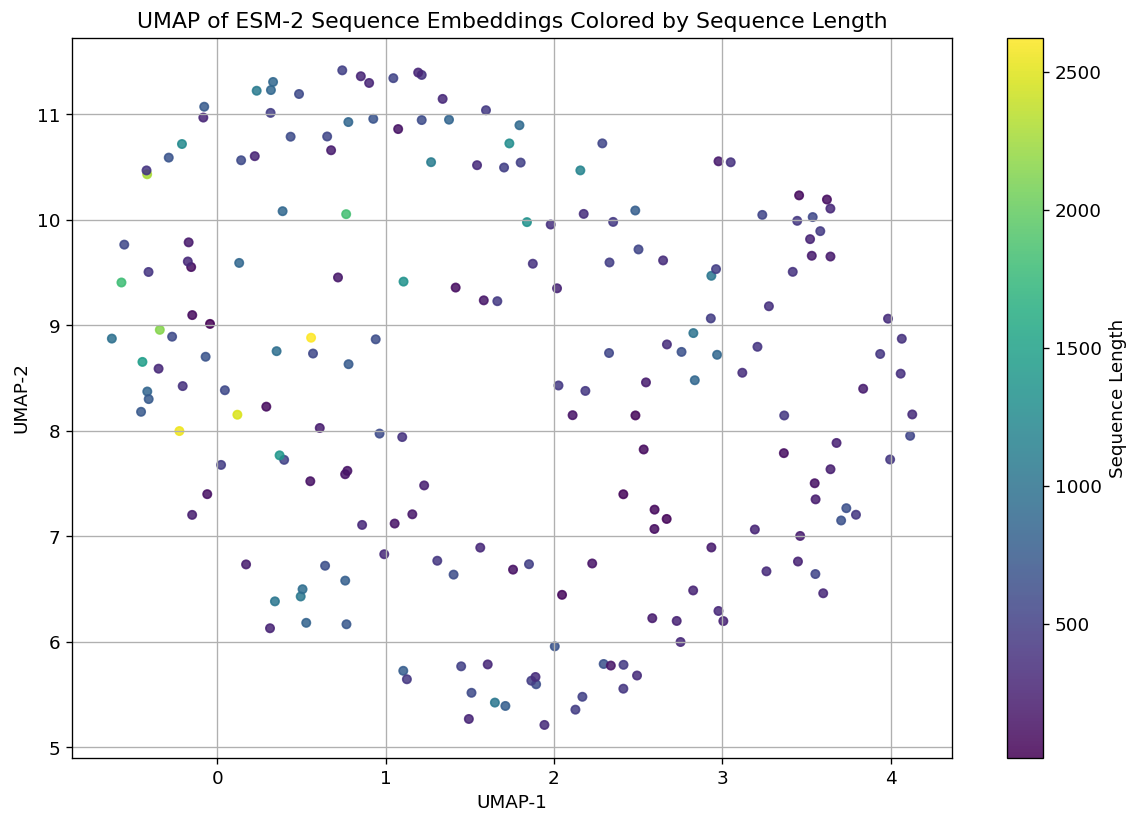

In [19]:

length_plot_path = os.path.join(FIG_DIR, "umap_by_sequence_length.png")

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    meta_df["umap_1"],
    meta_df["umap_2"],
    c=meta_df["seq_len"],
    s=25,
    alpha=0.85
)

plt.colorbar(scatter, label="Sequence Length")
plt.title("UMAP of ESM-2 Sequence Embeddings Colored by Sequence Length")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
save_current_figure(length_plot_path)
plt.show()


In [20]:

if "go_terms_list" in meta_df.columns:
    go_counter = Counter()
    for terms in meta_df["go_terms_list"]:
        go_counter.update(terms)

    common_go_df = pd.DataFrame(go_counter.most_common(20), columns=["go_term", "count"])
    common_go_df
else:
    print("No go_terms_list column found. Skipping GO-term frequency summary.")


In [21]:

SELECTED_GO = None

In [22]:

if "go_terms_list" in meta_df.columns and SELECTED_GO is not None:
    meta_df["has_selected_go"] = meta_df["go_terms_list"].apply(lambda terms: SELECTED_GO in terms)

    go_plot_path = os.path.join(FIG_DIR, f"umap_{SELECTED_GO.replace(':', '_')}.png")

    plt.figure(figsize=(10, 7))

    neg = meta_df[~meta_df["has_selected_go"]]
    pos = meta_df[meta_df["has_selected_go"]]

    plt.scatter(neg["umap_1"], neg["umap_2"], s=20, alpha=0.30, label="Other proteins")
    plt.scatter(pos["umap_1"], pos["umap_2"], s=35, alpha=0.95, label=SELECTED_GO)

    plt.title(f"UMAP Highlighting {SELECTED_GO}")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.legend()
    plt.tight_layout()
    save_current_figure(go_plot_path)
    plt.show()
else:
    print("Set SELECTED_GO to a GO term after reviewing the frequency table above.")


Set SELECTED_GO to a GO term after reviewing the frequency table above.


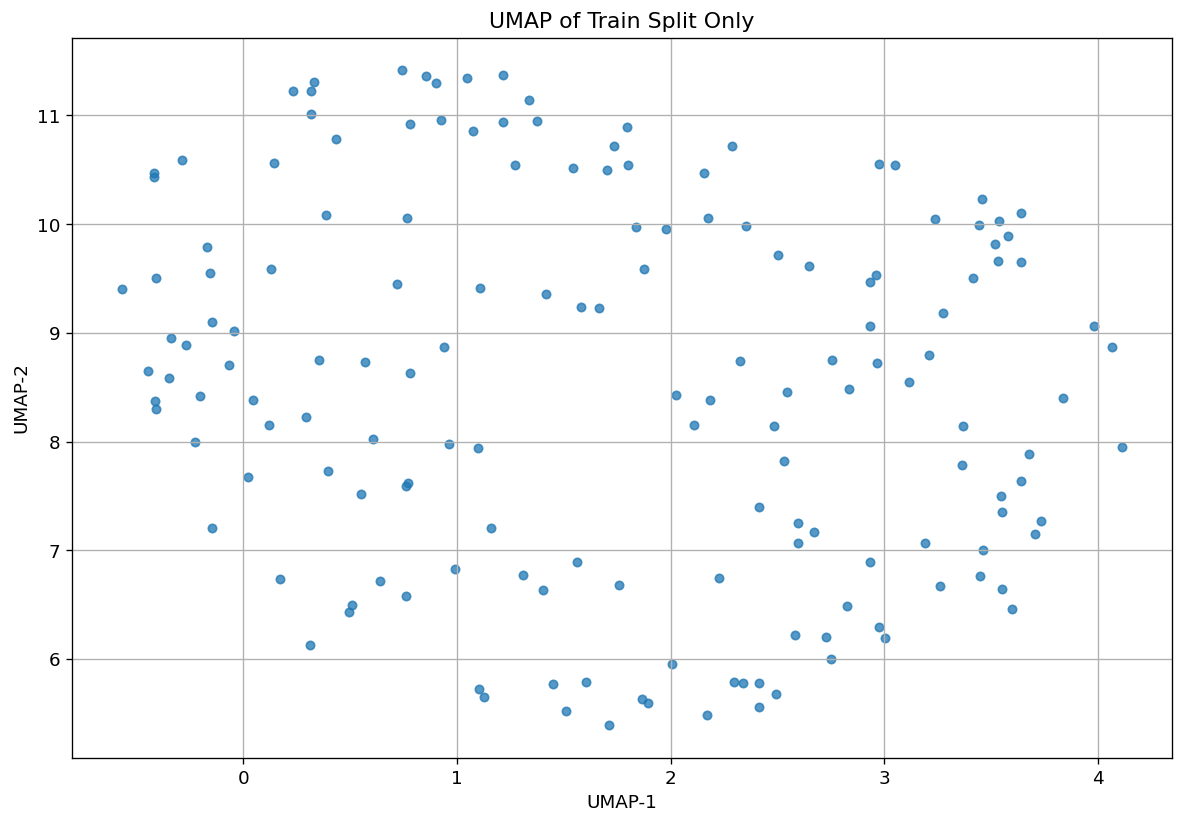

In [23]:

train_meta = meta_df[meta_df["split"] == "train"].copy()

plt.figure(figsize=(10, 7))
plt.scatter(train_meta["umap_1"], train_meta["umap_2"], s=25, alpha=0.75)
plt.title("UMAP of Train Split Only")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()


In [24]:

summary_table = pd.DataFrame({
    "metric": [
        "total proteins embedded",
        "embedding dimension",
        "train proteins",
        "val proteins",
        "test proteins",
        "UMAP neighbors",
        "UMAP min_dist",
        "UMAP metric"
    ],
    "value": [
        len(meta_df),
        X.shape[1],
        (meta_df["split"] == "train").sum(),
        (meta_df["split"] == "val").sum(),
        (meta_df["split"] == "test").sum(),
        UMAP_N_NEIGHBORS,
        UMAP_MIN_DIST,
        UMAP_METRIC
    ]
})

summary_table


,metric,value
0,total proteins embedded,199
1,embedding dimension,640
2,train proteins,159
3,val proteins,20
4,test proteins,20
5,UMAP neighbors,15
6,UMAP min_dist,0.1
7,UMAP metric,cosine
